In [1]:
from typing import List, Tuple
import drawsvg as dw
import json
import pandas as pd
import textwrap

In [2]:
class Point:
    def __init__(self, p:List[float]=None, movement:str=None):
        if isinstance(p,list):
            if len(p) == 2:
                self.p1 = float(p[0])
                self.p2 = float(p[1])
            elif len(p) == 1:
                self.p1 = float(p[0])
        else:
            try:
                self.p1 = float(p)
            except:
                print(f"No point inputted for movement:{movement}")
        

        self.movement=movement

    def __str__(self):
        cls = self.__class__.__name__
        try:
            return f"{cls}(p1={self.p1}, p2={self.p2}, movement={self.movement})"
        except:
            return f"{cls}(p1={self.p1}, movement={self.movement})"
        
    def __repr__(self):
        cls = self.__class__.__name__
        try:
            return f"{cls}(p1={self.p1}, p2={self.p2}, movement={self.movement})"
        except:
            return f"{cls}(p1={self.p1}, movement={self.movement})"

    def create_line(self, path, size):
        if self.movement == 'M':
            return path.M(self.p1*size,self.p2*size)
        elif self.movement == 'L':
            return path.L(self.p1*size,self.p2*size)
        elif self.movement == 'V':
            return path.V(self.p1*size)
        elif self.movement == 'H':
            return path.H(self.p1*size)
        elif self.movement == 'Z':
            return path.Z()

In [3]:
class Shape:
    def __init__(self, points:Point=None, path=None,stroke='black', fill='none', stroke_width=1):
        self.points = [points] if not isinstance(points,list) else points
        self.path = path if path is not None else dw.Path(stroke=stroke, stroke_width=stroke_width)
        self.stroke = stroke
        self.stroke_width= stroke_width
        self.fill = fill
        self.group = dw.Group(fill=fill)

    def create_shape(self, size):
        for point in self.points:
            self.path = point.create_line(self.path, size=size)

        self.group.append(self.path)
        
        return self.group

    def __str__(self):
        return "\n".join(str(point) for point in self.points)
    
    def __repr__(self):
        cls = self.__class__.__name__
        return f"{cls}(points=[{self.points[0]}...], path={self.path} stroke={self.stroke}, fill={self.fill})"


In [4]:
class Map:
    def __init__(self, shapes:Shape=None, map_name='map',width=300, height=300, origin='center', size_factor=None):
        self.shapes = [shapes] if not isinstance(shapes,list) else shapes
        self.map = dw.Drawing(width=width, height=height, origin=origin)
        self.map_name = map_name
        self.size_factor = size_factor

    def create_map(self, size=1):
        if self.size_factor is not None:
            size = self.size_factor
        
        for shape in self.shapes:
            self.map.append(shape.create_shape(size=size))

    def save_map(self, file_name:str=None, file_path=None ):
        self.map
        if file_name is None:
            if '.svg' in self.map_name:
                file_name = self.map_name
            else:
                file_name = self.map_name + '.svg'

        if file_path is not None:
            save_path = r'/'.join([file_path, file_name])
            self.map.save_svg(save_path)
        else:
            self.map.save_svg(file_name)

In [5]:
class Box:
    def __init__(self, province, electors, color,width=200, height=200, font_size=40,factor=1):
        self.province = province
        self.electors = electors
        self.color = color
        self.size = (width, height)
        self.font_size = font_size
        self.factor = 1

    def create_box(self):
        g = dw.Group(id=self.province, transform=f'scale({self.factor})')

        rect = dw.Rectangle(-100, -100, 200, 200, fill=self.color, stroke='white', stroke_width=2)
        g.append(rect)

        def split_text(text, max_width):
            wrapped_text = textwrap.fill(text, width=max_width)
            lines = wrapped_text.split(r'\n')
            try:
                return lines[1], lines[0]

            except:
                return lines[0], None
            
        # Split the province text if necessary
        available_width = self.size[0] - 30  # Assuming 10px padding on each side
        char_width = self.font_size * 0.5  # Approximate character width
        max_width = int(available_width / char_width) # Adjust this value based on your box size and font size
        top, bottom = split_text(self.province, max_width)
            # Add the text to the drawing
        province_top = dw.Text(top, self.font_size, 0, -20 if bottom else -30, center=True, fill='black',font_weight='bold',   stroke_width='0.01')
        if bottom is not None:
            province_bottom = dw.Text(bottom, self.font_size, 0, -55, center=True, fill='black',font_weight='bold', stroke_width='0.125')
        electors_txt = dw.Text(str(self.electors), 50, 0, 35, center=True, fill='black', font_weight='bold', stroke='white', stroke_width='0.125')

        g.append(electors_txt)
        g.append(province_top)
        if bottom:
            g.append(province_bottom)

        return g

In [6]:
def process_points(data):
    current_movement = None
    current_points = []
    points = []

    for item in data:
        if item.isalpha():  # Check if the item is a letter
            if current_movement is not None:
                points.append(Point(current_points,current_movement))

            current_movement = item
            current_points = []
        else:  # The item is a number
            current_points.append(item)

    if current_movement is not None:
        if current_movement != 'Z':
            points.append(Point(current_points,current_movement))
        else:
            points.append(Point(movement=current_movement))

    return points

def process_instructions(data: List[str]):
    result = []
    temp_list = []
    for item in data:
        temp_list.append(item)
        if item == 'Z':
            result.append(temp_list)
            temp_list = []
    return result


def process_shapes(data:List[list], fill='none', stroke_width=1):
    shapes = []
    for shape in data:
        shapes.append(Shape(process_points(shape), fill=fill, stroke_width=stroke_width))

    return shapes

def process_map(data, width=300, height=300, origin='center', size_factor=None):
    instructions = process_instructions(data)
    shapes = process_shapes(instructions)
    map_shape = Map(shapes=shapes, width=width, height=height, origin=origin, size_factor=size_factor)
    return map_shape

In [15]:
def create_col_image(boxes:List[Box], cols:int, image_size:Tuple[int,int]):
    num_boxes = len(boxes)
    rows = int(num_boxes/cols)
    max_width = image_size[0]
    max_height = image_size[1]

    d = dw.Drawing(image_size[0], image_size[1], origin='center', font_family="Helvetica")
    factor = min(max_width/(200*cols), max_height/(200*rows))
    
    g = dw.Group(transform=f'scale({factor})')
    calc_start = lambda num: -((200 * (num / 2)) - 100)
    start_x = calc_start(cols)
    start_y = calc_start(rows)

    x = start_x
    y = start_y
    k = 0
    for i in range(rows):
        for j in range(cols):
            g.append(dw.Use(boxes[k].create_box(), x, y))
            x += 200
            k += 1
        x = start_x
        y += 200

    d.append(g)

    return d

In [16]:
with open (r'C:\Users\Neil\Documents\Projects\Electoral-PH\Electoral-PH\image_creator\static\provinces.json') as file:
        provinces = json.load(file)

In [17]:
master_df = pd.read_csv(r'C:\Users\Neil\Documents\Projects\Electoral-PH\Electoral-PH\image_creator\static\data\master_data.csv', index_col=0)

In [18]:
master_df = master_df.astype({'year':str})
master_df['votes'] = pd.to_numeric(master_df['votes'])
master_df.head()

,year,position,province,color,candidate,votes
0,2004,President,Abra,#B0E0E6,Gloria_Arroyo,32644
1,2004,President,Agusan del Norte,#B0E0E6,Gloria_Arroyo,138402
2,2004,President,Agusan del Sur,#B0E0E6,Gloria_Arroyo,100998
3,2004,President,Aklan,#B0E0E6,Gloria_Arroyo,87197
4,2004,President,Albay,#B0E0E6,Gloria_Arroyo,172777


In [19]:
df = master_df.loc[(master_df['year']=='2010') &( master_df['position']=='President')]

In [20]:
idx = df.groupby('province')['votes'].idxmax()
df = df.loc[idx]

In [21]:
def create_instructions(data:list):
    instructions = data.strip()
    return instructions.split(" ")

In [22]:
data = []
for index, row in df.iterrows():
    province = row['province']
    instructions = create_instructions(provinces[province])

    data.append({'province': province, 'color':row['color'], 'instructions': instructions})

data.append({'province': 'Metro Manila', 'color': "none",'instructions': create_instructions(provinces['Metro Manila'])})
data.append({'province': 'Box', 'color': "none", 'instructions': create_instructions(provinces['Box'])})

In [23]:
shapes = []
for datum in data:
    instructions = process_instructions(datum['instructions'])
    shapes.extend(process_shapes(instructions, datum['color'], 0.5))

map_2010 = Map(shapes=shapes, width=800, height=1000, size_factor=3)

No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point inputted for movement:Z
No point i

In [24]:
map_2010.create_map()

In [25]:
map_2010.save_map(file_name="2010_presidential.svg")

In [26]:
electors_df = pd.read_csv(r'C:\Users\Neil\Documents\Projects\Electoral-PH\Electoral-PH\image_creator\static\data\2010_Reps.csv', index_col=0)
electors_df.head()

,province_id,electors
0,1,1
1,2,2
2,3,2
3,4,1
4,5,3


In [203]:
boxes = []

for index,row in df.iterrows():
    try:
        electors = electors_df.loc[electors_df['province'] == row['province'], 'electors'].values[0]
    except:
        print(f"ERROR: {row['province']}")
    province = "Cebu" if row['province']=='Cebu-2004' else row['province']
    font_size = 30 if province=='Maguindanao' else 32
    boxes.append(Box(province, electors, row['color'], font_size=font_size))

ERROR: Cebu
ERROR: Dinagat Islands
ERROR: Iligan
ERROR: Lapu-Lapu
ERROR: Malabon
ERROR: Navotas
ERROR: Taguig–Pateros


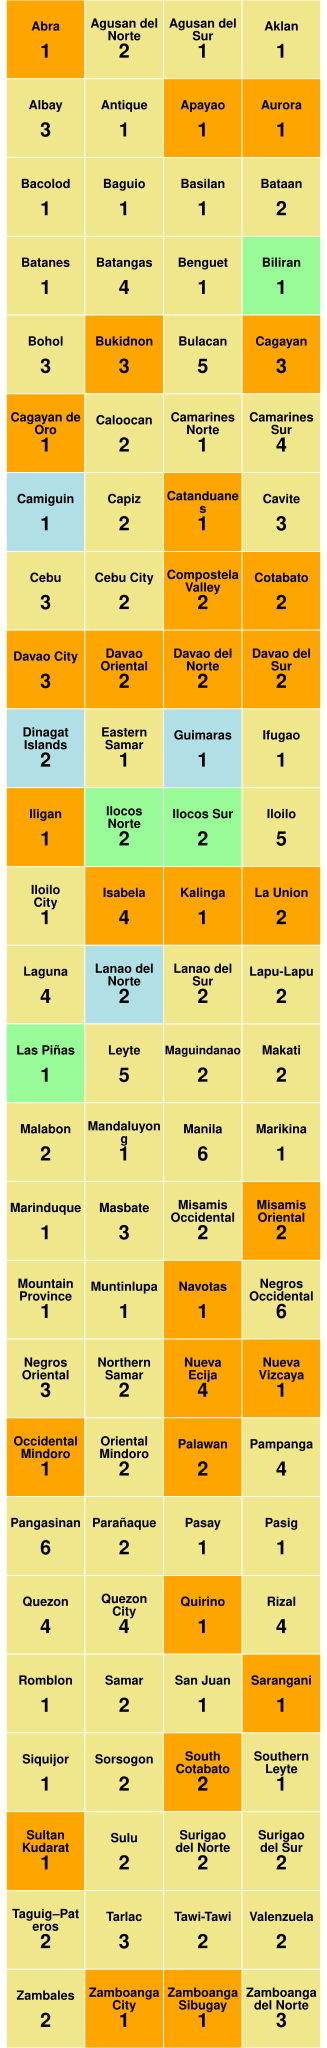

In [204]:
d = create_col_image(boxes, 4, (800,5000))
d

In [139]:
textwrap.fill("Tawi-Tawi", width=5)

'Tawi-\nTawi'